# Late Fusion ML Pipeline - ECG + PPG

Two separate classifiers trained on independent datasets, combined
via rule-based fusion logic. Architecture matches the embedded system:
ECG features → ECG model → ECG condition, PPG features → PPG model
→ PPG condition, both fed into the final decision layer.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay
)
from collections import Counter

## Stage 1 — Load and Clean Data

In [74]:
ecg = pd.read_csv('/home/hp/nadyon/praan/mitbih_project/Pan-Tompkins-FixedPoint/features_ecg/all_ecg_features.csv')
print('ECG shape:', ecg.shape)
print(ecg.head())
print('\nECG nulls:\n', ecg.isnull().sum())

ECG shape: (49, 12)
   record  n_beats  RR_mean_ms  RR_median_ms  RR_min_ms  RR_max_ms  SDNN_ms  \
0     100     2270         794           797        491       1177       32   
1     100     2270         794           797        491       1177       32   
2     101     1866         966           977        266       1275       64   
3     102     3060         589           722        113       1011      256   
4     103     2082         866           869        641       1352       32   

   RMSSD_ms  CVRR_q10  HR_bpm  mean_QRS_ms  SQI_q10  
0        32        41      75          206     1030  
1        32        41      75          206     1030  
2        32        67      62          286     1024  
3       256       445     101         2074     1031  
4        32        37      69          163     1026  

ECG nulls:
 record          0
n_beats         0
RR_mean_ms      0
RR_median_ms    0
RR_min_ms       0
RR_max_ms       0
SDNN_ms         0
RMSSD_ms        0
CVRR_q10        0
HR_bpm

In [75]:
ppg = pd.read_csv('/home/hp/nadyon/praan/ppg_project/ppg_ml_dataset.csv')
print('PPG shape:', ppg.shape)
print(ppg.head())
print('\nPPG nulls:\n', ppg.isnull().sum())

PPG shape: (68, 7)
   Subject  HeartRate  SpO2  RespRate  PerfusionIndex  RedAC  IRAC
0        1         76    93        15             164   1584  2315
1        2         51    79        15             143   2611  2080
2        3         75    87        15             139   1843  1932
3        4         69    84        15             181   2918  2770
4        5         41    85        15             194   2918  2916

PPG nulls:
 Subject           0
HeartRate         0
SpO2              0
RespRate          0
PerfusionIndex    0
RedAC             0
IRAC              0
dtype: int64


In [76]:
ecg = ecg.drop_duplicates()
ecg = ecg[
    (ecg['HR_bpm']     > 0)   &
    (ecg['HR_bpm']     < 250) &
    (ecg['RR_mean_ms'] > 0)   &
    (ecg['SDNN_ms']    >= 0)  &
    (ecg['RMSSD_ms']   >= 0)
].reset_index(drop=True)

ECG_FEATURES = ['RR_mean_ms', 'HR_bpm', 'SDNN_ms',
                'RMSSD_ms', 'mean_QRS_ms', 'SQI_q10']

print('ECG after cleaning:', ecg.shape)
print(ecg[ECG_FEATURES].describe())

ECG after cleaning: (48, 12)
        RR_mean_ms      HR_bpm      SDNN_ms     RMSSD_ms    mean_QRS_ms  \
count    48.000000   48.000000    48.000000    48.000000      48.000000   
mean    805.166667   77.312500   146.333333   171.333333   26089.041667   
std     167.929612   15.998878   163.934254   174.678469   96299.589274   
min     515.000000   50.000000    16.000000    16.000000       0.000000   
25%     693.500000   66.750000    64.000000    64.000000     177.000000   
50%     796.500000   75.000000   128.000000   128.000000     206.000000   
75%     894.750000   86.000000   256.000000   256.000000     250.750000   
max    1188.000000  116.000000  1024.000000  1024.000000  566064.000000   

           SQI_q10  
count    48.000000  
mean   1025.604167  
std       5.685890  
min    1000.000000  
25%    1024.000000  
50%    1026.000000  
75%    1029.000000  
max    1036.000000  


In [77]:
ppg = ppg.drop_duplicates()
ppg = ppg[
    (ppg['HeartRate']      > 0)   &
    (ppg['HeartRate']      < 200) &
    (ppg['SpO2']           > 0)   &
    (ppg['SpO2']           <= 100) &
    (ppg['PerfusionIndex'] > 0)
].reset_index(drop=True)

PPG_FEATURES = ['HeartRate', 'SpO2', 'RespRate',
                'PerfusionIndex', 'RedAC', 'IRAC']

print('PPG after cleaning:', ppg.shape)
print(ppg[PPG_FEATURES].describe())

PPG after cleaning: (68, 7)
        HeartRate       SpO2  RespRate  PerfusionIndex        RedAC  \
count   68.000000  68.000000      68.0       68.000000    68.000000   
mean    75.338235  84.088235      15.0      163.235294  2500.235294   
std     19.177576   5.248270       0.0       42.330300   603.129330   
min     37.000000  70.000000      15.0       66.000000   948.000000   
25%     67.500000  82.000000      15.0      132.500000  2019.750000   
50%     75.000000  84.500000      15.0      166.000000  2546.500000   
75%     85.000000  87.000000      15.0      199.250000  2879.750000   
max    111.000000  96.000000      15.0      264.000000  3777.000000   

              IRAC  
count    68.000000  
mean   2416.455882  
std     633.741306  
min     926.000000  
25%    1930.500000  
50%    2396.500000  
75%    2902.500000  
max    3834.000000  


## Stage 2 — Label Generation

ECG labels use clinical HR thresholds plus HRV and signal quality checks.

PPG labels use dataset-relative SpO2 and PI thresholds (25th percentile)
because the empirical SpO2 formula produces systematically lower absolute
values than a calibrated pulse oximeter. Using the fixed clinical threshold
of 92% would label 93% of subjects as hypoxic and destroy the classifier.

ECG label distribution:
label
Normal         36
Bradycardia     6
Tachycardia     5
Low_HRV         1
Name: count, dtype: int64


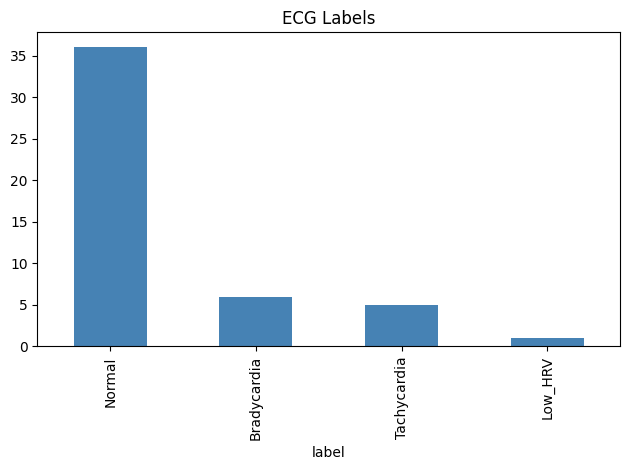

In [78]:
def ecg_label(row):
    if row['HR_bpm'] > 100:
        return 'Tachycardia'
    elif row['HR_bpm'] < 60:
        return 'Bradycardia'
    elif row['SDNN_ms'] < 20:
        return 'Low_HRV'
    elif row['SQI_q10'] < 800:
        return 'Noisy'
    else:
        return 'Normal'

ecg['label'] = ecg.apply(ecg_label, axis=1)

print('ECG label distribution:')
print(ecg['label'].value_counts())

ecg['label'].value_counts().plot(kind='bar', title='ECG Labels', color='steelblue')
plt.tight_layout()
plt.show()

SpO2 25th percentile threshold: 82.0
PI   25th percentile threshold: 132.5

PPG label distribution:
label
Normal           31
Bradycardia      13
Low_SpO2         10
Low_Perfusion     7
Tachycardia       7
Name: count, dtype: int64


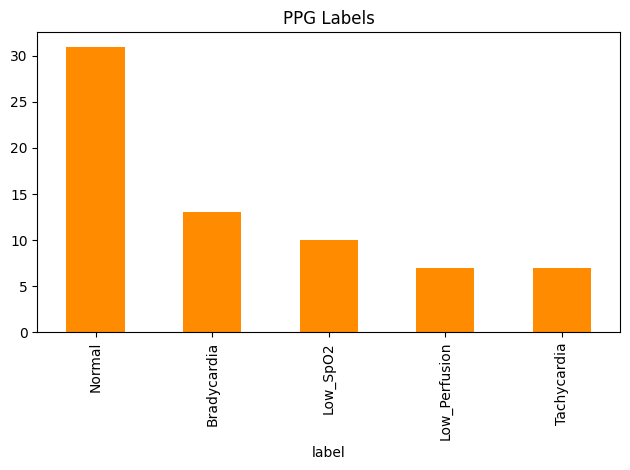

In [79]:
spo2_threshold = ppg['SpO2'].quantile(0.25)
pi_threshold   = ppg['PerfusionIndex'].quantile(0.25)

print(f'SpO2 25th percentile threshold: {spo2_threshold:.1f}')
print(f'PI   25th percentile threshold: {pi_threshold:.1f}')

def ppg_label(row):
    if row['HeartRate'] > 100:
        return 'Tachycardia'
    elif row['HeartRate'] < 60:
        return 'Bradycardia'
    elif row['SpO2'] < spo2_threshold:
        return 'Low_SpO2'
    elif row['PerfusionIndex'] < pi_threshold:
        return 'Low_Perfusion'
    else:
        return 'Normal'

ppg['label'] = ppg.apply(ppg_label, axis=1)

print('\nPPG label distribution:')
print(ppg['label'].value_counts())

ppg['label'].value_counts().plot(kind='bar', title='PPG Labels', color='darkorange')
plt.tight_layout()
plt.show()

## Stage 3 — Feature Preparation and Normalization

In [80]:
X_ecg = ecg[ECG_FEATURES].values
y_ecg = ecg['label'].values

scaler_ecg   = StandardScaler()
X_ecg_scaled = scaler_ecg.fit_transform(X_ecg)

print('ECG feature matrix:', X_ecg_scaled.shape)
print('ECG classes:', np.unique(y_ecg))

ECG feature matrix: (48, 6)
ECG classes: ['Bradycardia' 'Low_HRV' 'Normal' 'Tachycardia']


In [81]:
X_ppg = ppg[PPG_FEATURES].values
y_ppg = ppg['label'].values

scaler_ppg   = StandardScaler()
X_ppg_scaled = scaler_ppg.fit_transform(X_ppg)

print('PPG feature matrix:', X_ppg_scaled.shape)
print('PPG classes:', np.unique(y_ppg))

PPG feature matrix: (68, 6)
PPG classes: ['Bradycardia' 'Low_Perfusion' 'Low_SpO2' 'Normal' 'Tachycardia']


## Stage 4 — Model Training

ECG MODEL RESULTS
Test accuracy : 0.900
CV accuracy   : 0.938 +/- 0.051

              precision    recall  f1-score   support

 Bradycardia       0.00      0.00      0.00         1
      Normal       0.89      1.00      0.94         8
 Tachycardia       1.00      1.00      1.00         1

    accuracy                           0.90        10
   macro avg       0.63      0.67      0.65        10
weighted avg       0.81      0.90      0.85        10



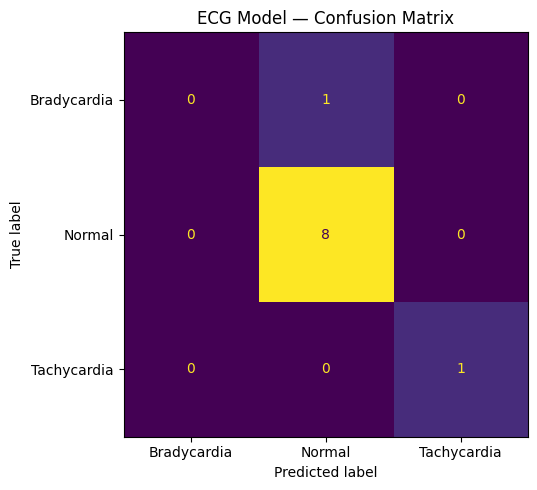

In [82]:
X_ecg_train, X_ecg_test, y_ecg_train, y_ecg_test = train_test_split(
    X_ecg_scaled, y_ecg, test_size=0.2, random_state=42
    # stratify removed — ECG dataset too small (1 Low_HRV sample)
)

ecg_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
ecg_model.fit(X_ecg_train, y_ecg_train)

cv_scores    = cross_val_score(ecg_model, X_ecg_scaled, y_ecg, cv=5)
y_ecg_pred   = ecg_model.predict(X_ecg_test)

print('ECG MODEL RESULTS')
print('=' * 55)
print(f'Test accuracy : {accuracy_score(y_ecg_test, y_ecg_pred):.3f}')
print(f'CV accuracy   : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print()
print(classification_report(y_ecg_test, y_ecg_pred))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_ecg_test, y_ecg_pred, ax=ax, colorbar=False
)
ax.set_title('ECG Model — Confusion Matrix')
plt.tight_layout()
plt.show()

PPG MODEL RESULTS
Test accuracy : 0.857
CV accuracy   : 0.926 +/- 0.045

               precision    recall  f1-score   support

  Bradycardia       1.00      1.00      1.00         3
Low_Perfusion       1.00      0.50      0.67         2
     Low_SpO2       1.00      1.00      1.00         2
       Normal       0.75      1.00      0.86         6
  Tachycardia       0.00      0.00      0.00         1

     accuracy                           0.86        14
    macro avg       0.75      0.70      0.70        14
 weighted avg       0.82      0.86      0.82        14



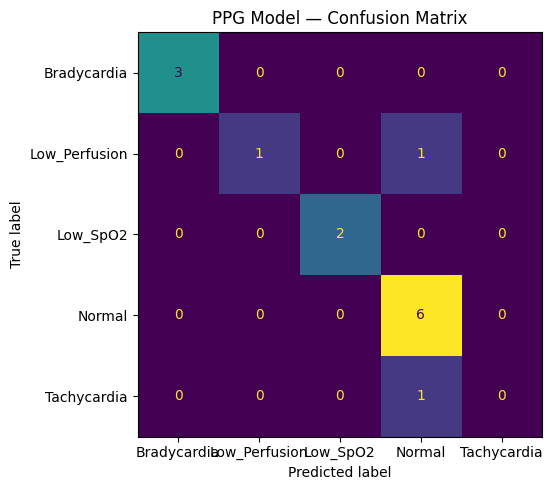

In [83]:
X_ppg_train, X_ppg_test, y_ppg_train, y_ppg_test = train_test_split(
    X_ppg_scaled, y_ppg, test_size=0.2, random_state=42, stratify=y_ppg
)

ppg_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
ppg_model.fit(X_ppg_train, y_ppg_train)

cv_scores_ppg = cross_val_score(ppg_model, X_ppg_scaled, y_ppg, cv=5)
y_ppg_pred    = ppg_model.predict(X_ppg_test)

print('PPG MODEL RESULTS')
print('=' * 55)
print(f'Test accuracy : {accuracy_score(y_ppg_test, y_ppg_pred):.3f}')
print(f'CV accuracy   : {cv_scores_ppg.mean():.3f} +/- {cv_scores_ppg.std():.3f}')
print()
print(classification_report(y_ppg_test, y_ppg_pred))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_ppg_test, y_ppg_pred, ax=ax, colorbar=False
)
ax.set_title('PPG Model — Confusion Matrix')
plt.tight_layout()
plt.show()

## Stage 5 — Decision Tree Rules

These rules map directly to the embedded C if-else code.

In [84]:
print('ECG DECISION TREE RULES')
print('=' * 50)
print(export_text(ecg_model, feature_names=ECG_FEATURES))

print()
print('PPG DECISION TREE RULES')
print('=' * 50)
print(export_text(ppg_model, feature_names=PPG_FEATURES))

ECG DECISION TREE RULES
|--- RR_mean_ms <= 1.33
|   |--- RR_mean_ms <= -1.27
|   |   |--- class: Tachycardia
|   |--- RR_mean_ms >  -1.27
|   |   |--- RMSSD_ms <= -0.85
|   |   |   |--- class: Low_HRV
|   |   |--- RMSSD_ms >  -0.85
|   |   |   |--- class: Normal
|--- RR_mean_ms >  1.33
|   |--- class: Bradycardia


PPG DECISION TREE RULES
|--- HeartRate <= -0.88
|   |--- class: Bradycardia
|--- HeartRate >  -0.88
|   |--- SpO2 <= -0.50
|   |   |--- class: Low_SpO2
|   |--- SpO2 >  -0.50
|   |   |--- HeartRate <= 1.48
|   |   |   |--- PerfusionIndex <= -0.78
|   |   |   |   |--- class: Low_Perfusion
|   |   |   |--- PerfusionIndex >  -0.78
|   |   |   |   |--- class: Normal
|   |   |--- HeartRate >  1.48
|   |   |   |--- class: Tachycardia



## Stage 6 — Late Fusion Inference

In [85]:
def final_decision(ecg_result, ppg_result):
    ecg_abnormal = ecg_result != 'Normal'
    ppg_abnormal = ppg_result != 'Normal'

    if ecg_abnormal and ppg_result == 'Low_SpO2':
        return 'CRITICAL'
    if ecg_result == 'Tachycardia' and ppg_result == 'Tachycardia':
        return 'CRITICAL'
    if ecg_result == 'Bradycardia' and ppg_result == 'Bradycardia':
        return 'CRITICAL'
    if ecg_abnormal and ppg_abnormal:
        return 'DUAL_ALERT'
    if ecg_result in ('Tachycardia', 'Bradycardia'):
        return 'CARDIAC_ALERT'
    if ecg_result == 'Low_HRV':
        return 'HRV_ALERT'
    if ppg_result == 'Low_SpO2':
        return 'OXYGEN_ALERT'
    if ppg_result == 'Low_Perfusion':
        return 'CIRCULATION_ALERT'
    if ppg_result in ('Tachycardia', 'Bradycardia'):
        return 'CARDIAC_ALERT'
    if ecg_result == 'Noisy' or ppg_abnormal:
        return 'CHECK_SIGNAL'
    return 'NORMAL'


ecg_preds_all = ecg_model.predict(X_ecg_scaled)
ppg_preds_all = ppg_model.predict(X_ppg_scaled)
n_pairs       = min(len(ecg_preds_all), len(ppg_preds_all))

fusion_results = [
    final_decision(ecg_preds_all[i], ppg_preds_all[i])
    for i in range(n_pairs)
]

print('FUSION OUTPUT DISTRIBUTION')
print('=' * 40)
for decision, count in Counter(fusion_results).most_common():
    print(f'  {decision:<22}: {count}')

FUSION OUTPUT DISTRIBUTION
  NORMAL                : 18
  CARDIAC_ALERT         : 7
  OXYGEN_ALERT          : 7
  CIRCULATION_ALERT     : 6
  CRITICAL              : 5
  DUAL_ALERT            : 4
  HRV_ALERT             : 1


In [86]:
print('SINGLE PATIENT DEMO')
print('=' * 100)

ecg_sample = X_ecg_scaled[0].reshape(1, -1)
ppg_sample = X_ppg_scaled[0].reshape(1, -1)

ecg_result = ecg_model.predict(ecg_sample)[0]
ppg_result = ppg_model.predict(ppg_sample)[0]
decision   = final_decision(ecg_result, ppg_result)

print(f'ECG raw features : ')
print(f'{dict(zip(ECG_FEATURES, X_ecg[0]))}')
print(f'PPG raw features : ') 
print(f'{dict(zip(PPG_FEATURES, X_ppg[0]))}')
print(f'ECG model output : {ecg_result}')
print(f'PPG model output : {ppg_result}')
print(f'FINAL DECISION   : {decision}')

SINGLE PATIENT DEMO
ECG raw features : 
{'RR_mean_ms': 794, 'HR_bpm': 75, 'SDNN_ms': 32, 'RMSSD_ms': 32, 'mean_QRS_ms': 206, 'SQI_q10': 1030}
PPG raw features : 
{'HeartRate': 76, 'SpO2': 93, 'RespRate': 15, 'PerfusionIndex': 164, 'RedAC': 1584, 'IRAC': 2315}
ECG model output : Normal
PPG model output : Normal
FINAL DECISION   : NORMAL


## Stage 7 — Export Decision Tree as C Code

In [87]:
def tree_to_c(model, feature_names, function_name):
    tree = model.tree_
    classes = model.classes_
    lines = []
    lines.append('/* Auto-generated from DecisionTreeClassifier */')
    lines.append(f'/* Features: {", ".join(feature_names)} */')
    lines.append('')
    args = ', '.join(f'float {f}' for f in feature_names)
    lines.append(f'const char* {function_name}({args})')
    lines.append('{')

    def recurse(node, depth):
        indent = '    ' * (depth + 1)
        if tree.feature[node] != -2:
            feat   = feature_names[tree.feature[node]]
            thresh = tree.threshold[node]
            lines.append(f'{indent}if ({feat} <= {thresh:.6f}f) {{')
            recurse(tree.children_left[node],  depth + 1)
            lines.append(f'{indent}}} else {{')
            recurse(tree.children_right[node], depth + 1)
            lines.append(f'{indent}}}')
        else:
            label = classes[np.argmax(tree.value[node])]
            lines.append(f'{indent}return "{label}";')

    recurse(0, 0)
    lines.append('}')
    return '\n'.join(lines)


ecg_c = tree_to_c(ecg_model, ECG_FEATURES, 'ecg_classify')
ppg_c = tree_to_c(ppg_model, PPG_FEATURES, 'ppg_classify')

with open('ecg_model.c', 'w') as f:
    f.write(ecg_c)

with open('ppg_model.c', 'w') as f:
    f.write(ppg_c)

print('ecg_model.c and ppg_model.c saved')
print()
print(ecg_c[:600])
print('...')

ecg_model.c and ppg_model.c saved

/* Auto-generated from DecisionTreeClassifier */
/* Features: RR_mean_ms, HR_bpm, SDNN_ms, RMSSD_ms, mean_QRS_ms, SQI_q10 */

const char* ecg_classify(float RR_mean_ms, float HR_bpm, float SDNN_ms, float RMSSD_ms, float mean_QRS_ms, float SQI_q10)
{
    if (RR_mean_ms <= 1.331960f) {
        if (RR_mean_ms <= -1.270778f) {
            return "Tachycardia";
        } else {
            if (RMSSD_ms <= -0.852380f) {
                return "Low_HRV";
            } else {
                return "Normal";
            }
        }
    } else {
        return "Bradycardia";
    }
}
...


In [88]:
fusion_c = '''/* Late fusion decision logic */
#include <string.h>

typedef enum {
    DECISION_NORMAL,
    DECISION_CARDIAC_ALERT,
    DECISION_HRV_ALERT,
    DECISION_OXYGEN_ALERT,
    DECISION_CIRCULATION_ALERT,
    DECISION_DUAL_ALERT,
    DECISION_CRITICAL,
    DECISION_CHECK_SIGNAL
} FusionDecision;

FusionDecision fusion_decide(const char *ecg, const char *ppg)
{
    int ea = strcmp(ecg, "Normal") != 0;
    int pa = strcmp(ppg, "Normal") != 0;

    if (ea && strcmp(ppg, "Low_SpO2") == 0)      return DECISION_CRITICAL;
    if (strcmp(ecg,"Tachycardia")==0 && strcmp(ppg,"Tachycardia")==0) return DECISION_CRITICAL;
    if (strcmp(ecg,"Bradycardia")==0 && strcmp(ppg,"Bradycardia")==0) return DECISION_CRITICAL;
    if (ea && pa)                                 return DECISION_DUAL_ALERT;
    if (strcmp(ecg,"Tachycardia")==0 || strcmp(ecg,"Bradycardia")==0) return DECISION_CARDIAC_ALERT;
    if (strcmp(ecg,"Low_HRV")==0)                return DECISION_HRV_ALERT;
    if (strcmp(ppg,"Low_SpO2")==0)               return DECISION_OXYGEN_ALERT;
    if (strcmp(ppg,"Low_Perfusion")==0)          return DECISION_CIRCULATION_ALERT;
    if (strcmp(ppg,"Tachycardia")==0 || strcmp(ppg,"Bradycardia")==0) return DECISION_CARDIAC_ALERT;
    if (strcmp(ecg,"Noisy")==0 || pa)            return DECISION_CHECK_SIGNAL;
    return DECISION_NORMAL;
}
'''

with open('fusion_logic.c', 'w') as f:
    f.write(fusion_c)

print('fusion_logic.c saved')
print(fusion_c)

fusion_logic.c saved
/* Late fusion decision logic */
#include <string.h>

typedef enum {
    DECISION_NORMAL,
    DECISION_CARDIAC_ALERT,
    DECISION_HRV_ALERT,
    DECISION_OXYGEN_ALERT,
    DECISION_CIRCULATION_ALERT,
    DECISION_DUAL_ALERT,
    DECISION_CRITICAL,
    DECISION_CHECK_SIGNAL
} FusionDecision;

FusionDecision fusion_decide(const char *ecg, const char *ppg)
{
    int ea = strcmp(ecg, "Normal") != 0;
    int pa = strcmp(ppg, "Normal") != 0;

    if (ea && strcmp(ppg, "Low_SpO2") == 0)      return DECISION_CRITICAL;
    if (strcmp(ecg,"Tachycardia")==0 && strcmp(ppg,"Tachycardia")==0) return DECISION_CRITICAL;
    if (strcmp(ecg,"Bradycardia")==0 && strcmp(ppg,"Bradycardia")==0) return DECISION_CRITICAL;
    if (ea && pa)                                 return DECISION_DUAL_ALERT;
    if (strcmp(ecg,"Tachycardia")==0 || strcmp(ecg,"Bradycardia")==0) return DECISION_CARDIAC_ALERT;
    if (strcmp(ecg,"Low_HRV")==0)                return DECISION_HRV_ALERT;
    if (strcmp(

In [89]:
print("ECG scaler means:", scaler_ecg.mean_.tolist())
print("ECG scaler stds: ", scaler_ecg.scale_.tolist())
print("PPG scaler means:", scaler_ppg.mean_.tolist())
print("PPG scaler stds: ", scaler_ppg.scale_.tolist())

ECG scaler means: [805.1666666666666, 77.3125, 146.33333333333334, 171.33333333333334, 26089.041666666668, 1025.6041666666667]
ECG scaler stds:  [166.17113835507723, 15.831345818238784, 162.21761789508423, 172.84932423613606, 95291.18882338106, 5.626350146606788]
PPG scaler means: [75.33823529411765, 84.08823529411765, 15.0, 163.23529411764707, 2500.235294117647, 2416.455882352941]
PPG scaler stds:  [19.036041894350312, 5.209536769848293, 1.0, 42.01789452373372, 598.6781301001462, 629.0641843672497]


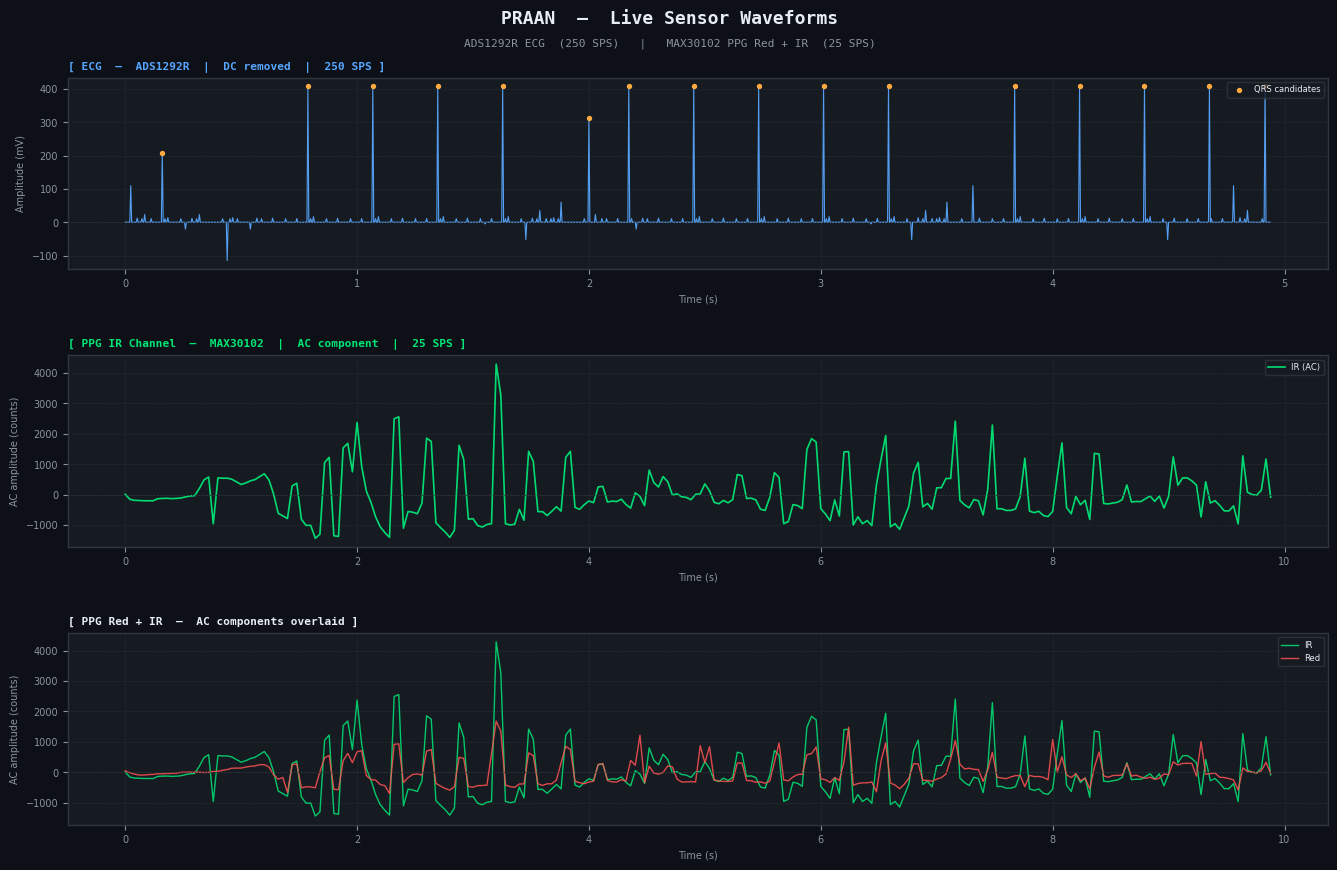

Saved: praan_waveforms.png


In [90]:
# ── SIGNAL PLOTS ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Point these at your actual log files ───────────────────────────────────
ECG_LOG = '/home/hp/nadyon/gc2025A/scripts/uart_logs/ecg_20260502_164129.txt'
PPG_LOG = '/home/hp/nadyon/gc2025A/scripts/uart_logs/ppg_20260502_162954.txt'

# ── Load ECG ───────────────────────────────────────────────────────────────
ecg_raw_vals = []
with open(ECG_LOG) as f:
    for line in f:
        line = line.strip()
        try:
            v = float(line)
            if -300.0 < v < 800.0:          # same saturation filter as C pipeline
                ecg_raw_vals.append(v)
        except ValueError:
            pass

ecg_arr = np.array(ecg_raw_vals)
ecg_dc  = np.median(ecg_arr)
ecg_arr = ecg_arr - ecg_dc                  # DC removal — same as C pipeline
ecg_t   = np.arange(len(ecg_arr)) / 250.0  # 250 SPS → seconds

# ── Load PPG ───────────────────────────────────────────────────────────────
red_vals, ir_vals = [], []
skip = 2
with open(PPG_LOG) as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) == 2:
            try:
                r, ir = int(parts[0]), int(parts[1])
                if skip > 0:
                    skip -= 1
                    continue
                red_vals.append(r)
                ir_vals.append(ir)
            except ValueError:
                pass

red_arr = np.array(red_vals, dtype=float)
ir_arr  = np.array(ir_vals,  dtype=float)
ppg_t   = np.arange(len(ir_arr)) / 25.0    # 25 SPS → seconds

# AC extraction for display — rolling mean removes slow DC drift
# window = 25 samples = 1 second at 25 SPS
def rolling_mean(x, w=25):
    kernel = np.ones(w) / w
    padded = np.pad(x, (w//2, w//2), mode='edge')
    return np.convolve(padded, kernel, mode='valid')[:len(x)]

red_ac = red_arr - rolling_mean(red_arr)
ir_ac  = ir_arr  - rolling_mean(ir_arr)

# ── Plot ───────────────────────────────────────────────────────────────────
BG     = '#0d1117'
PANEL  = '#161b22'
BORDER = '#30363d'
TEXT   = '#e6edf3'
SUBTEXT= '#8b949e'
ACCENT = '#58a6ff'
GREEN  = '#00e676'
RED    = '#ff5252'

fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor=BG)
fig.subplots_adjust(hspace=0.45, left=0.07, right=0.97, top=0.91, bottom=0.08)

fig.text(0.5, 0.97, 'PRAAN  —  Live Sensor Waveforms',
         ha='center', fontsize=13, fontweight='bold',
         color=TEXT, fontfamily='monospace')
fig.text(0.5, 0.945, 'ADS1292R ECG  (250 SPS)   |   MAX30102 PPG Red + IR  (25 SPS)',
         ha='center', fontsize=8, color=SUBTEXT, fontfamily='monospace')

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
        spine.set_linewidth(1)
    ax.tick_params(colors=SUBTEXT, labelsize=7)
    ax.grid(True, color=BORDER, linewidth=0.5, linestyle='--', alpha=0.6)
    ax.xaxis.label.set_color(SUBTEXT)
    ax.yaxis.label.set_color(SUBTEXT)

# ── Plot 1: ECG ────────────────────────────────────────────────────────────
axes[0].plot(ecg_t, ecg_arr, color=ACCENT, linewidth=0.8, alpha=0.95)
axes[0].set_title('[ ECG  —  ADS1292R  |  DC removed  |  250 SPS ]',
                  color=ACCENT, fontsize=8, fontfamily='monospace',
                  fontweight='bold', loc='left', pad=6)
axes[0].set_ylabel('Amplitude (mV)', fontsize=7)
axes[0].set_xlabel('Time (s)', fontsize=7)
axes[0].axhline(0, color=BORDER, linewidth=0.8, linestyle=':')

# annotate peak region
peak_thresh = ecg_arr.max() * 0.5
peak_idx    = np.where(ecg_arr > peak_thresh)[0]
if len(peak_idx) > 0:
    axes[0].scatter(ecg_t[peak_idx], ecg_arr[peak_idx],
                    color='#ffab40', s=8, zorder=5, label='QRS candidates')
    axes[0].legend(fontsize=6, facecolor=PANEL, edgecolor=BORDER,
                   labelcolor=TEXT, loc='upper right')

# ── Plot 2: PPG IR (cleaner, larger signal) ────────────────────────────────
axes[1].plot(ppg_t, ir_ac, color=GREEN, linewidth=1.2, alpha=0.95, label='IR (AC)')
axes[1].set_title('[ PPG IR Channel  —  MAX30102  |  AC component  |  25 SPS ]',
                  color=GREEN, fontsize=8, fontfamily='monospace',
                  fontweight='bold', loc='left', pad=6)
axes[1].set_ylabel('AC amplitude (counts)', fontsize=7)
axes[1].set_xlabel('Time (s)', fontsize=7)
axes[1].axhline(0, color=BORDER, linewidth=0.8, linestyle=':')
axes[1].legend(fontsize=6, facecolor=PANEL, edgecolor=BORDER,
               labelcolor=TEXT, loc='upper right')

# ── Plot 3: PPG Red + IR overlaid ─────────────────────────────────────────
axes[2].plot(ppg_t, ir_ac,  color=GREEN, linewidth=1.0, alpha=0.85, label='IR')
axes[2].plot(ppg_t, red_ac, color=RED,   linewidth=1.0, alpha=0.85, label='Red')
axes[2].set_title('[ PPG Red + IR  —  AC components overlaid ]',
                  color=TEXT, fontsize=8, fontfamily='monospace',
                  fontweight='bold', loc='left', pad=6)
axes[2].set_ylabel('AC amplitude (counts)', fontsize=7)
axes[2].set_xlabel('Time (s)', fontsize=7)
axes[2].axhline(0, color=BORDER, linewidth=0.8, linestyle=':')
axes[2].legend(fontsize=6, facecolor=PANEL, edgecolor=BORDER,
               labelcolor=TEXT, loc='upper right')

plt.savefig('praan_waveforms.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved: praan_waveforms.png')

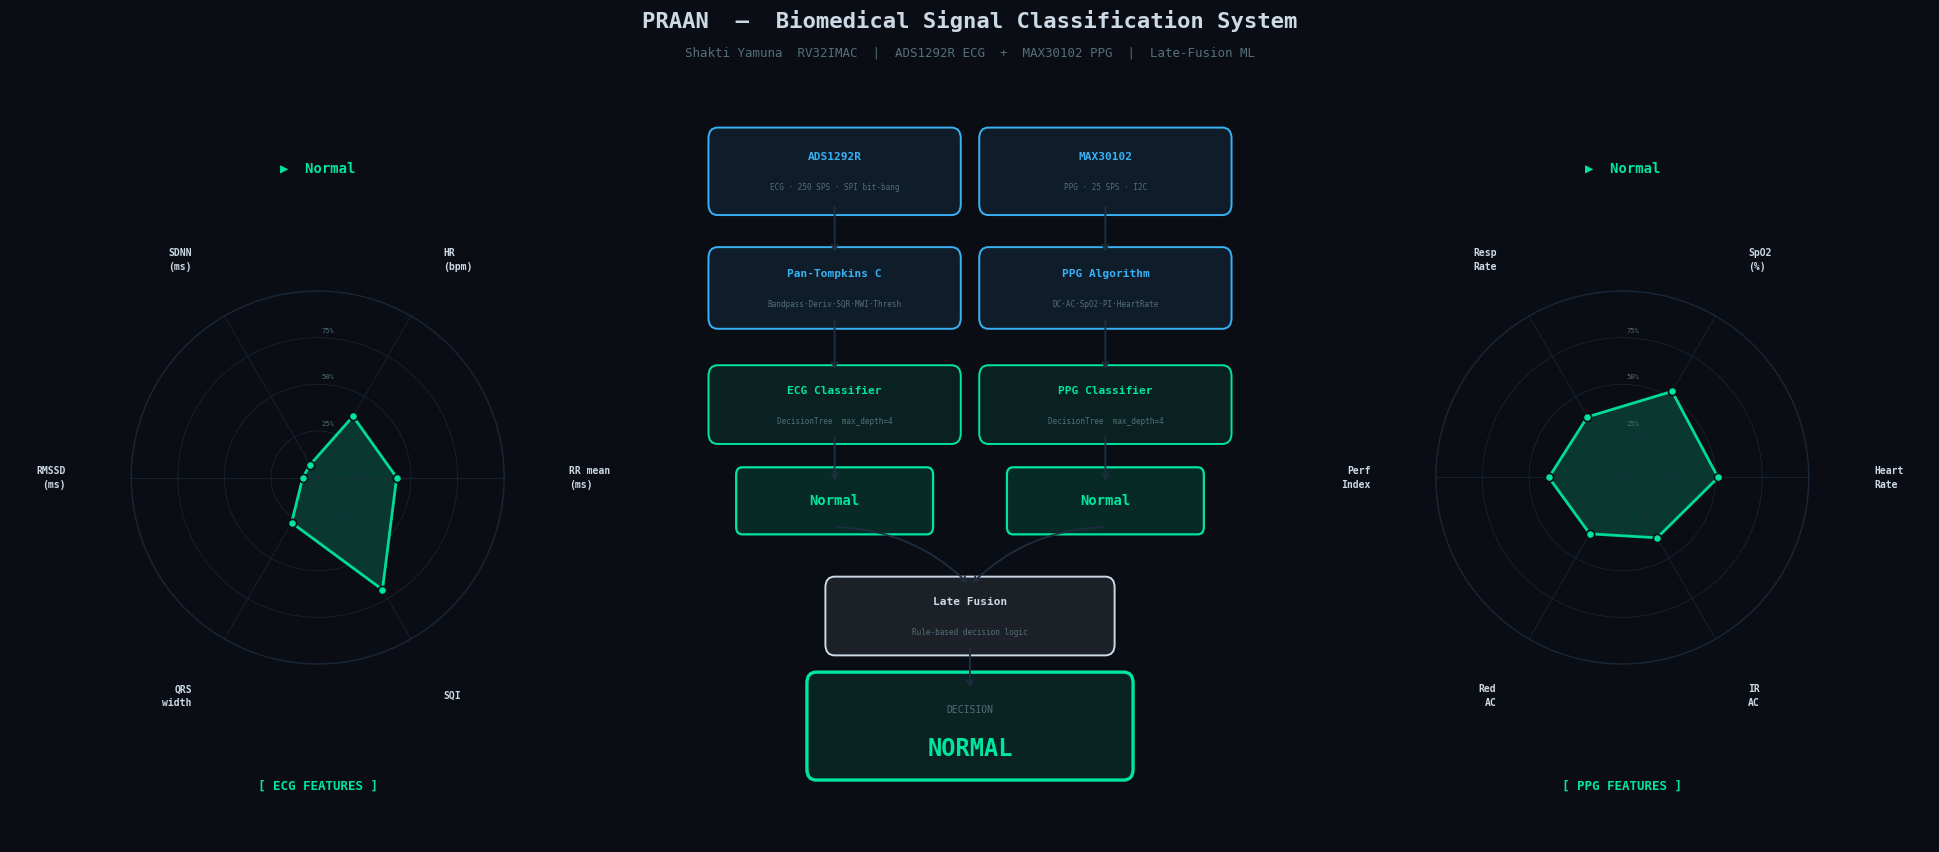

Saved: praan_dashboard.png


In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np
import re

# ── Paste your pipeline output here ───────────────────────────────────────
ecg_output = """
ECG_FEATURES: RR_mean_ms=800.00 HR_bpm=75.00 SDNN_ms=32.00 RMSSD_ms=32.00 mean_QRS_ms=206.00 SQI_q10=1025.00
ECG_SCALED:   -0.031092 -0.146071 -0.704815 -0.806097 -0.271621 -0.107382
ECG_CLASS:    Normal
"""
ppg_output = """
PPG_FEATURES: HeartRate=75 SpO2=86 RespRate=15 PerfusionIndex=144 RedAC=1935 IRAC=2012
PPG_SCALED:   -0.017768 0.366974 0.000000 -0.457788 -0.944139 -0.642949
PPG_CLASS:    Normal
"""

# ── Parser ─────────────────────────────────────────────────────────────────
def parse_output(text, tag_features, tag_scaled, tag_class):
    feat_line   = next(l for l in text.splitlines() if tag_features in l)
    scaled_line = next(l for l in text.splitlines() if tag_scaled   in l)
    class_line  = next(l for l in text.splitlines() if tag_class    in l)
    pairs  = re.findall(r'(\w+)=([\-\d.]+)', feat_line)
    raw    = {k: float(v) for k, v in pairs}
    scaled = np.array(list(map(float, scaled_line.split(':')[1].split()))).reshape(1, -1)
    label  = class_line.split(':')[1].strip()
    return raw, scaled, label

ecg_raw, ecg_vec, _ = parse_output(ecg_output, 'ECG_FEATURES', 'ECG_SCALED', 'ECG_CLASS')
ppg_raw, ppg_vec, _ = parse_output(ppg_output, 'PPG_FEATURES', 'PPG_SCALED', 'PPG_CLASS')
ecg_label = ecg_model.predict(ecg_vec)[0]
ppg_label = ppg_model.predict(ppg_vec)[0]
decision  = final_decision(ecg_label, ppg_label)

# ── Colours ────────────────────────────────────────────────────────────────
BG      = '#0a0e14'
PANEL   = '#0f1520'
BORDER  = '#1e2d40'
TEXT    = '#cdd9e5'
SUBTEXT = '#546e7a'
ACCENT  = '#38b2f5'
GREEN   = '#00e5a0'
AMBER   = '#ffab40'
RED_C   = '#ff5370'

LABEL_COLOR = {
    'Normal':        GREEN,
    'Tachycardia':   AMBER,
    'Bradycardia':   '#40c4ff',
    'Low_HRV':       AMBER,
    'Low_SpO2':      RED_C,
    'Low_Perfusion': '#ff9100',
    'Noisy':         SUBTEXT,
}
DECISION_COLOR = {
    'NORMAL':            GREEN,
    'CARDIAC_ALERT':     AMBER,
    'HRV_ALERT':         AMBER,
    'OXYGEN_ALERT':      RED_C,
    'CIRCULATION_ALERT': AMBER,
    'DUAL_ALERT':        RED_C,
    'CRITICAL':          '#ff1744',
    'CHECK_SIGNAL':      SUBTEXT,
}
dec_color = DECISION_COLOR.get(decision, GREEN)
ecg_color = LABEL_COLOR.get(ecg_label, ACCENT)
ppg_color = LABEL_COLOR.get(ppg_label, ACCENT)

# ── Normalise ──────────────────────────────────────────────────────────────
ecg_ranges = {
    'RR_mean_ms':  (515,  1188),
    'HR_bpm':      (50,   116),
    'SDNN_ms':     (16,   256),
    'RMSSD_ms':    (16,   256),
    'mean_QRS_ms': (150,  350),
    'SQI_q10':     (1000, 1036),
}
ppg_ranges = {
    'HeartRate':      (37,  111),
    'SpO2':           (70,  100),
    'RespRate':       (12,  20),
    'PerfusionIndex': (66,  264),
    'RedAC':          (948, 3777),
    'IRAC':           (926, 3834),
}

def normalise(raw, ranges):
    return [max(0.08, min(1.0, (raw.get(k, lo) - lo) / max(hi - lo, 1)))
            for k, (lo, hi) in ranges.items()]

ecg_norm = normalise(ecg_raw, ecg_ranges)
ppg_norm = normalise(ppg_raw, ppg_ranges)

ecg_labels_r = ['RR mean\n(ms)', 'HR\n(bpm)', 'SDNN\n(ms)', 'RMSSD\n(ms)', 'QRS\nwidth', 'SQI']
ppg_labels_r  = ['Heart\nRate', 'SpO2\n(%)', 'Resp\nRate', 'Perf\nIndex', 'Red\nAC', 'IR\nAC']

# ── Radar helper ────────────────────────────────────────────────────────────
def radar_chart(ax, labels, values, color, title, label_result):
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    vals   = values + [values[0]]
    angs   = angles + [angles[0]]

    # grid rings
    for r in [0.25, 0.5, 0.75, 1.0]:
        rx = [r * np.cos(a) for a in np.linspace(0, 2*np.pi, 300)]
        ry = [r * np.sin(a) for a in np.linspace(0, 2*np.pi, 300)]
        lw = 1.0 if r == 1.0 else 0.5
        ax.plot(rx, ry, color=BORDER, linewidth=lw, alpha=0.8)
        if r < 1.0:
            ax.text(0.02, r + 0.03, f'{int(r*100)}%',
                    color=SUBTEXT, fontsize=5, fontfamily='monospace')

    # spokes
    for a in angles:
        ax.plot([0, np.cos(a)], [0, np.sin(a)],
                color=BORDER, linewidth=0.6, alpha=0.7)

    # filled shape
    px = [v * np.cos(a) for v, a in zip(vals, angs)]
    py = [v * np.sin(a) for v, a in zip(vals, angs)]
    ax.fill(px, py, alpha=0.2, color=color)
    ax.plot(px, py, color=color, linewidth=2.0, alpha=0.95)
    ax.scatter([v * np.cos(a) for v, a in zip(values, angles)],
               [v * np.sin(a) for v, a in zip(values, angles)],
               color=color, s=35, zorder=5,
               edgecolors=BG, linewidth=1.2)

    # axis labels — push further out
    for a, lbl in zip(angles, labels):
        x = 1.35 * np.cos(a)
        y = 1.35 * np.sin(a)
        ha = 'center'
        if np.cos(a) >  0.25: ha = 'left'
        if np.cos(a) < -0.25: ha = 'right'
        ax.text(x, y, lbl, ha=ha, va='center', color=TEXT,
                fontsize=7, fontfamily='monospace', fontweight='bold',
                linespacing=1.4)

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.65, 1.65)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor(PANEL)

    # bottom title, top result badge
    ax.text(0, -1.62, title, ha='center', va='top',
            color=color, fontsize=9, fontfamily='monospace', fontweight='bold')
    ax.text(0,  1.62, f'▶  {label_result}', ha='center', va='bottom',
            color=color, fontsize=10, fontweight='bold', fontfamily='monospace')

# ── Figure: 1 row × 3 cols ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 9), facecolor=BG)

gs = gridspec.GridSpec(
    1, 3,
    figure=fig,
    left=0.02, right=0.98,
    top=0.87,  bottom=0.06,
    wspace=0.06
)

fig.text(0.5, 0.965, 'PRAAN  —  Biomedical Signal Classification System',
         ha='center', fontsize=16, fontweight='bold',
         color=TEXT, fontfamily='monospace')
fig.text(0.5, 0.933, 'Shakti Yamuna  RV32IMAC  |  ADS1292R ECG  +  MAX30102 PPG  |  Late-Fusion ML',
         ha='center', fontsize=9, color=SUBTEXT, fontfamily='monospace')

# ── Left: ECG radar ────────────────────────────────────────────────────────
ax_ecg = fig.add_subplot(gs[0, 0], facecolor=PANEL)
for sp in ax_ecg.spines.values(): sp.set_edgecolor(BORDER)
radar_chart(ax_ecg, ecg_labels_r, ecg_norm, ecg_color,
            '[ ECG FEATURES ]', ecg_label)

# ── Right: PPG radar ───────────────────────────────────────────────────────
ax_ppg = fig.add_subplot(gs[0, 2], facecolor=PANEL)
for sp in ax_ppg.spines.values(): sp.set_edgecolor(BORDER)
radar_chart(ax_ppg, ppg_labels_r, ppg_norm, ppg_color,
            '[ PPG FEATURES ]', ppg_label)

# ── Centre: pipeline flow ──────────────────────────────────────────────────
ax_mid = fig.add_subplot(gs[0, 1], facecolor=BG)
ax_mid.set_xlim(0, 10)
ax_mid.set_ylim(0, 10)
ax_mid.axis('off')
for sp in ax_mid.spines.values(): sp.set_edgecolor(BORDER)

def fbox(ax, x, y, w, h, top, bot, col):
    r = FancyBboxPatch((x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.15', lw=1.4,
        edgecolor=col, facecolor=col + '18')
    ax.add_patch(r)
    ax.text(x, y + 0.2,  top, ha='center', va='center',
            color=col,    fontsize=8,   fontweight='bold', fontfamily='monospace')
    ax.text(x, y - 0.22, bot, ha='center', va='center',
            color=SUBTEXT, fontsize=5.5, fontfamily='monospace')

def farrow(ax, x, y1, y2, rad=0):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
        arrowprops=dict(arrowstyle='->', color=BORDER, lw=1.4,
                        connectionstyle=f'arc3,rad={rad}'))

# sensor row
fbox(ax_mid, 2.8, 9.2, 3.8, 0.9,  'ADS1292R',      'ECG · 250 SPS · SPI bit-bang', ACCENT)
fbox(ax_mid, 7.2, 9.2, 3.8, 0.9,  'MAX30102',       'PPG · 25 SPS · I2C',           ACCENT)
farrow(ax_mid, 2.8, 8.75, 8.05)
farrow(ax_mid, 7.2, 8.75, 8.05)

# processing row
fbox(ax_mid, 2.8, 7.6, 3.8, 0.82, 'Pan-Tompkins C', 'Bandpass·Deriv·SQR·MWI·Thresh', ACCENT)
fbox(ax_mid, 7.2, 7.6, 3.8, 0.82, 'PPG Algorithm',  'DC·AC·SpO2·PI·HeartRate',        ACCENT)
farrow(ax_mid, 2.8, 7.19, 6.44)
farrow(ax_mid, 7.2, 7.19, 6.44)

# classifier row
fbox(ax_mid, 2.8, 6.0,  3.8, 0.78, 'ECG Classifier', 'DecisionTree  max_depth=4', ecg_color)
fbox(ax_mid, 7.2, 6.0,  3.8, 0.78, 'PPG Classifier', 'DecisionTree  max_depth=4', ppg_color)
farrow(ax_mid, 2.8, 5.61, 4.91)
farrow(ax_mid, 7.2, 5.61, 4.91)

# label badges
for x, lbl, col in [(2.8, ecg_label, ecg_color), (7.2, ppg_label, ppg_color)]:
    b = FancyBboxPatch((x - 1.5, 4.32), 3.0, 0.72,
        boxstyle='round,pad=0.1', lw=1.6,
        edgecolor=col, facecolor=col + '22')
    ax_mid.add_patch(b)
    ax_mid.text(x, 4.68, lbl, ha='center', va='center',
        color=col, fontsize=10, fontweight='bold', fontfamily='monospace')

# converge to fusion
ax_mid.annotate('', xy=(5.0, 3.52), xytext=(2.8, 4.32),
    arrowprops=dict(arrowstyle='->', color=BORDER, lw=1.3,
                    connectionstyle='arc3,rad=-0.2'))
ax_mid.annotate('', xy=(5.0, 3.52), xytext=(7.2, 4.32),
    arrowprops=dict(arrowstyle='->', color=BORDER, lw=1.3,
                    connectionstyle='arc3,rad=0.2'))

# fusion box
fbox(ax_mid, 5.0, 3.1, 4.4, 0.78, 'Late Fusion', 'Rule-based decision logic', TEXT)
farrow(ax_mid, 5.0, 2.71, 2.08)

# decision box
d = FancyBboxPatch((2.5, 1.0), 5.0, 1.18,
    boxstyle='round,pad=0.15', lw=2.4,
    edgecolor=dec_color, facecolor=dec_color + '1a')
ax_mid.add_patch(d)
ax_mid.text(5.0, 1.82, 'DECISION', ha='center', va='center',
    color=SUBTEXT, fontsize=7, fontfamily='monospace')
ax_mid.text(5.0, 1.28, decision, ha='center', va='center',
    color=dec_color, fontsize=17, fontweight='bold', fontfamily='monospace')

plt.savefig('praan_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved: praan_dashboard.png')